# Final Project

## Part 0 Project Proposal
Before we do the project, you will need to create a repository
1. Create the project remotely on GitHub.  You will want to include a README
2. Install GitHub Desktop.
3. From the remote repo, clone down to your local and use github desktop to create it.
4. Copy the notebook into your local repo
5. Commit and push

***Invite me and the GA to your repo***

As you make changes locally, commit and push them. 

To complete the proposal. You will record the following in your README

1. The kind of data you want to find
2. The question/s you want to answer with the data.
3. URLs for the site/s that have the data you want.

***Note: You must aquire the data via an API or Web scraping.  Downloading a file will not get points.***

All code for your project will be recorded in this note book. Create extra code cells as needed.


# Part 1: Data aquisition
    1. Get raw data and put it into files. If needed, gather a representative amount of data.  Then append additional data as available.
    


In [16]:
# Part 1: Put code here

import requests

urls = [
    "https://www.reddit.com/r/trendingsubreddits.json",
    "https://www.reddit.com/r/all/.json",
    "https://www.reddit.com/r/popular/.json",
    "https://www.reddit.com/r/news/.json",
    "https://www.reddit.com/r/gaming/.json",
    "https://www.reddit.com/r/technology/.json"
]

headers = {
    "User-Agent": "my project"
}

all_comments = []

for url in urls:
    response = requests.get(url, headers=headers)
    data = response.json()

    for post in data["data"]["children"]:
        all_comments.append(post["data"]["num_comments"])
# empty 
titles = []

# Loop 
for post in data["data"]["children"]:
    titles.append(post["data"]["title"])


with open("titles.txt", "w", encoding="utf-8") as file:
    for title in titles:
        file.write(title + "\n")

print("Data collected successfully!")

Data collected successfully!


## Part 2 Data processing

1. Process the raw data and store results in a file as needed.
2. Do analysis of the data
   

In [19]:
from collections import Counter
import spacy


nlp = spacy.load("en_core_web_sm")

with open("titles.txt", "r", encoding="utf-8") as file:
    text = file.read().lower()


doc = nlp(text)
comments = []

clean_words = []
for token in doc:
    if not token.is_stop and len(token.text) > 2:
        clean_words.append(token.text)

# count words
word_count = Counter(clean_words)

# print top 10
print(word_count.most_common(10))

[('google', 6), ('bill', 3), ('state', 3), ('said', 3), ('claude', 2), ('powered', 2), ('entire', 2), ('moves', 2), ('u.s', 2), ('cost', 2)]


## Part 3 Visualization

1. Create good graphs
2. Give narative conclusions explaining what is being demonstrated in the visualizations.

   

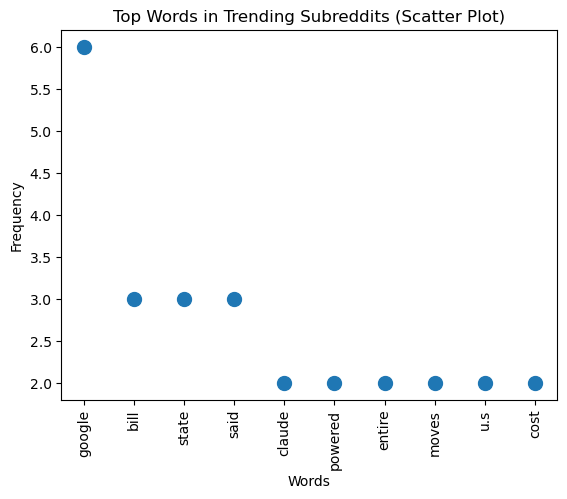

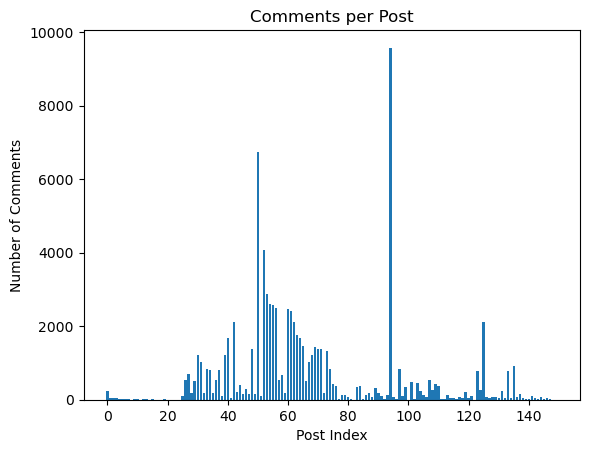

In [26]:
import matplotlib.pyplot as plt


top_words = word_count.most_common(10)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.scatter(range(len(words)), counts, s=100)

plt.xticks(range(len(words)), words, rotation=90)

plt.title("Top Words in Trending Subreddits (Scatter Plot)")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()


plt.bar(range(len(all_comments)), all_comments)
plt.title("Comments per Post")
plt.xlabel("Post Index")
plt.ylabel("Number of Comments")
plt.show()

In [ ]:
# Data Manipulation 

#1. What data manipulation steps did you perform?
#I took the Reddit data and pulled out just the titles. Then I made all the words lowercase so they would be counted the same. After that, I split the text into individual words and counted how many times each word shows up. In the end, I looked at the most common words.

#2. Why did you manipulate the data this way?
#The original data had a lot of extra stuff I didn’t need. I only cared about the words in the titles, so I simplified it. Making everything lowercase and splitting the words helped keep things consistent and easier to work with.

#3. How does this make the data usable for your final presentation?
#Now the data is turned into word counts, which makes it easy to create charts. This helps show which words are used the most and makes the results easier to understand.


In [ ]:
Graphs#1
This is a scatter plot of the top 10 words used in the post titles on Reddit.
The length of each bar represents the number of times the word appears.
For instance, words appearing more frequently indicate what the most frequently discussed topics are in the selected subreddits.
This gives insight into the most talked about topics on Reddit.

In [ ]:
graphs#2
This bar graph shows the number of comments for each Reddit post obtained.
The bars represent individual posts and the bar's length represents the number of comments it received.
The graph reveals that certain posts are more popular than others.
For instance, it is clear that some posts receive a greater level of engagement, perhaps by posts containing interesting or interesting features.